In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

movies_df = pd.read_csv("Datasets/clean_movies.csv")
# cast_df = pd.read_csv("Datasets/clean_cast.csv")
# crew_df = pd.read_csv("Datasets/clean_crew.csv")
keyword_df = pd.read_csv("Datasets/keywords.csv")
# keyword_df = pd.read_csv("Datasets/clean_keyword.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
# production_df = pd.read_csv("Datasets/clean_production.csv")

In [18]:
#merge genres and keywords
# combined_df = pd.merge(genres_df, keyword_df, on='id')

In [19]:
movies_df = pd.merge(movies_df, keyword_df, on='id')

In [20]:
#try a new supervised model that will make a guess about whether a movie will be popular / profitable

#sift out low value rows
movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 5)]
movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
profit_avg = movies_df['profit'].mean().round(2)
pop_avg = movies_df['popularity'].mean()

print(f"The average profit from this collection is ${profit_avg}")
print(f"The average popularity from this collection is {pop_avg}")

The average profit from this collection is $60945729.68
The average popularity from this collection is 10.010041778505897


In [21]:
# movies_df['is_flop'] = (movies_df['popularity'] < pop_avg) & (movies_df['profit'] < 0)
# print(movies_df['is_flop'].value_counts())


In [22]:
#create a new derived value.  is_flop popularity < mean, profit < mean use 
#try a wider context
movies_df['is_flop'] = (movies_df['profit'] < 0)
print(movies_df['is_flop'].value_counts())

is_flop
False    3774
True     1567
Name: count, dtype: int64


In [23]:
X = movies_df['movie_text'].values
y = movies_df['is_flop'].values

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


vectorizers = {
    "CountVectorizer": CountVectorizer(),
    "TfidfVectorizer": TfidfVectorizer(),
    "HashVectorizer": HashingVectorizer(n_features=2**20)
}

classifiers = {
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(),
    "LogisticRegression": LogisticRegression(),
    "LinearSVC": LinearSVC()
}

# Create the pipelines combining the above vectorizers and classifiers
# Suggestion: Create the pipelines as a dictionary of name->pipeline where `name` describes the vectorizer and classifier used.
pipelines = {
    # "count-kn": make_pipeline(CountVectorizer(stop_words='english'), KNeighborsClassifier()),
    # # "Embed-SVM": make_pipeline(SentenceTransformerEmbedding(), SVC()),
    # "Hashing-SVM": make_pipeline(HashingVectorizer(n_features=2**20), SVC()),
    # "Hashing-Logistic": make_pipeline(HashingVectorizer(n_features=2**20), LogisticRegression()),
    # "TfIdf-KN": make_pipeline(TfidfVectorizer(stop_words='english'), KNeighborsClassifier(n_neighbors=3)),
    "TfIdf-Logistic": make_pipeline(TfidfVectorizer(stop_words='english'), LogisticRegression(class_weight='balanced',max_iter=1000)),
    # "Linear-SVC": make_pipeline(TfidfVectorizer(stop_words='english'), LinearSVC(class_weight='balanced'))   
    # "Embed-Logistic": make_pipeline(SentenceTransformerEmbedding(),LogisticRegression())
}



In [26]:
#abbreviated for power point

# #create a new derived value.  is_flop popularity < mean, profit < mean use 
# movies_df['is_flop'] = (movies_df['profit'] < 0)
# print(movies_df['is_flop'].value_counts())

# #create data and target for the model
# X = movies_df['movie_text'].values
# y = movies_df['is_flop'].values

# #train, test and split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# #make pipeline (abbv.) balance the class weight, remove stop words
# pipelines = {"TfIdf-Logistic": make_pipeline(TfidfVectorizer(stop_words='english'), 
#                 LogisticRegression(class_weight='balanced',max_iter=1000))}

In [27]:
#abbrerviated for the power point

# from sklearn.metrics import accuracy_score
# from sklearn.metrics import confusion_matrix

# #evaluation of the model

# #get accuracy score
# for name, pipe in pipelines.items():
#     pipe.fit(X_train, y_train)
#     y_pred = pipe.predict(X_test)
#     score = accuracy_score(y_test, y_pred)

# #get classification report
# for name, pipe in pipelines.items():
#     y_pred = pipe.predict(X_test)

# #get confusion matrix
# ypred = pipelines['TfIdf-Logistic'].predict(X_test)

# mat = confusion_matrix(y_test, ypred)


In [28]:
# pipelines["count-kn"].fit(X_train,y_train)
# pipelines["Hashing-SVM"].fit(X_train,y_train)
# pipelines["Hashing-Logistic"].fit(X_train,y_train)
# pipelines["TfIdf-KN"].fit(X_train,y_train)
# pipelines["TfIdf-Logistic"].fit(X_train,y_train)
# pipelines["Linear-SVC"].fit(X_train,y_train)

In [29]:
from sklearn.metrics import accuracy_score

acc_scores_list = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    
    print(f"{name} Score: {score}")
    
    acc_scores_list.append({'Model': name, 'Accuracy': score})

TfIdf-Logistic Score: 0.6688493919550982


In [30]:
from sklearn.metrics import classification_report

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    
    print(f"\n" + "*"*55)
    print(f" CLASSIFICATION REPORT: {name}")
    print("*"*55)
    
    print(classification_report(y_test, y_pred))


*******************************************************
 CLASSIFICATION REPORT: TfIdf-Logistic
*******************************************************
              precision    recall  f1-score   support

       False       0.77      0.75      0.76       752
        True       0.45      0.47      0.46       317

    accuracy                           0.67      1069
   macro avg       0.61      0.61      0.61      1069
weighted avg       0.67      0.67      0.67      1069



In [35]:

#thanks Gemini for helping me get these keyword scores:

vec = pipelines["TfIdf-Logistic"].named_steps['tfidfvectorizer']
clf = pipelines["TfIdf-Logistic"].named_steps['logisticregression']

# vec = pipelines["Linear-SVC"].named_steps['tfidfvectorizer']
# clf = pipelines["Linear-SVC"].named_steps['linearsvc']

weights = pd.Series(clf.coef_[0], index=vec.get_feature_names_out())

print("Top 10 Flop Keywords:")
print(weights.sort_values(ascending=False).head(10))

print("\nTop 10 Success Keywords:")
print(weights.sort_values(ascending=True).head(10))



Top 10 Flop Keywords:
independent    2.803326
drama          2.757930
save           1.691794
film           1.434633
set            1.289411
thriller       1.264834
rock           1.152787
murder         1.141501
affair         1.133094
brother        1.101936
dtype: float64

Top 10 Success Keywords:
secret                 -1.990020
sequel                 -1.775640
house                  -1.652034
duringcreditsstinger   -1.353487
school                 -1.255649
3d                     -1.237800
self                   -1.204374
relationship           -1.201873
aftercreditsstinger    -1.158832
marvel                 -1.089906
dtype: float64


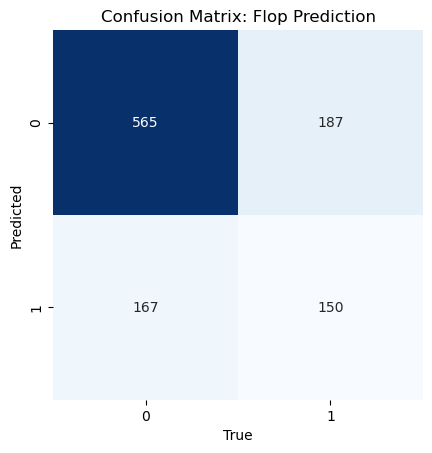

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

ypred = pipelines['TfIdf-Logistic'].predict(X_test)

matrix = confusion_matrix(y_test, ypred)

sns.heatmap(matrix, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues')

plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix: Flop Prediction')
plt.show()
